# Tox21 Exploratory Data Analysis (EDA)

This notebook performs a full EDA workflow for Tox21 toxicity prediction data using the `smiles` column and 12 binary assay endpoints.

Coverage in this notebook:
- Data loading (single CSV or split train/test CSV files)
- Missing value analysis per assay
- Class imbalance analysis per assay
- SMILES validity check using RDKit
- Visualization of class positives and missing-label patterns

In [8]:
# Core imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style for consistent notebook visuals
sns.set_theme(style="whitegrid", context="notebook")

# Assay columns provided in the project specification
ASSAY_COLUMNS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase", "NR-ER", "NR-ER-LBD",
    "NR-PPAR-gamma", "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]

DATA_DIR = Path("../data")

## 1) Load Dataset and Inspect Basics

In [9]:
def load_tox21_dataframe(data_dir: Path) -> tuple[pd.DataFrame, list[Path]]:
    """Load Tox21 from a single CSV or from split train/test CSV files."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Data directory not found: {data_dir.resolve()}")

    # Priority 1: canonical single-file dataset
    canonical_file = data_dir / "tox21.csv"
    if canonical_file.exists():
        df_single = pd.read_csv(canonical_file)
        return df_single, [canonical_file]

    # Priority 2: split train/test files (common naming patterns)
    csv_files = sorted(data_dir.glob("*.csv"))
    train_files = [p for p in csv_files if "train" in p.stem.lower()]
    test_files = [p for p in csv_files if "test" in p.stem.lower()]

    if train_files and test_files:
        selected_files = sorted(train_files + test_files)
    else:
        raise FileNotFoundError(
            f"Could not find 'tox21.csv' or train/test split CSV files in {data_dir.resolve()}"
        )

    # Concatenate split files into one dataframe for unified EDA
    frames = []
    for path in selected_files:
        frame = pd.read_csv(path)
        frame["__source_file__"] = path.name
        frames.append(frame)

    combined_df = pd.concat(frames, ignore_index=True)
    return combined_df, selected_files


# Load dataset
df, loaded_files = load_tox21_dataframe(DATA_DIR)

# Validate required columns
required_columns = ["smiles"] + ASSAY_COLUMNS
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Loaded file(s):")
for file_path in loaded_files:
    print(f"  - {file_path}")

print(f"\nShape: {df.shape}")
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head(5).to_string(index=False))

Loaded file(s):
  - ../data/tox21.csv

Shape: (7831, 14)

Column dtypes:
NR-AR            float64
NR-AR-LBD        float64
NR-AhR           float64
NR-Aromatase     float64
NR-ER            float64
NR-ER-LBD        float64
NR-PPAR-gamma    float64
SR-ARE           float64
SR-ATAD5         float64
SR-HSE           float64
SR-MMP           float64
SR-p53           float64
mol_id               str
smiles               str
dtype: object

First 5 rows:
 NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  SR-ARE  SR-ATAD5  SR-HSE  SR-MMP  SR-p53   mol_id                                                    smiles
   0.0        0.0     1.0           NaN    NaN        0.0            0.0     1.0       0.0     0.0     0.0     0.0  TOX3021                              CCOc1ccc2nc(S(N)(=O)=O)sc2c1
   0.0        0.0     0.0           0.0    0.0        0.0            0.0     NaN       0.0     NaN     0.0     0.0  TOX3020                                 CCN1C(=O)NC(c2ccccc2)C1=O
  

## 2) Missing Value Analysis

In [10]:
total_samples = len(df)

# Build a per-assay missingness summary table
missing_summary_rows = []
for assay in ASSAY_COLUMNS:
    nan_count = int(df[assay].isna().sum())
    pct_missing = (nan_count / total_samples * 100.0) if total_samples > 0 else np.nan
    missing_summary_rows.append({
        "assay": assay,
        "total_samples": total_samples,
        "NaN_count": nan_count,
        "pct_missing": pct_missing
    })

missing_df = pd.DataFrame(missing_summary_rows).sort_values("pct_missing", ascending=False)

print("Missing Value Summary by Assay")
print(missing_df.to_string(
    index=False,
    formatters={"pct_missing": lambda x: f"{x:.2f}%"}
))

Missing Value Summary by Assay
        assay  total_samples  NaN_count pct_missing
       SR-MMP           7831       2021      25.81%
 NR-Aromatase           7831       2010      25.67%
       SR-ARE           7831       1999      25.53%
        NR-ER           7831       1638      20.92%
NR-PPAR-gamma           7831       1381      17.64%
       SR-HSE           7831       1364      17.42%
       NR-AhR           7831       1282      16.37%
    NR-AR-LBD           7831       1073      13.70%
       SR-p53           7831       1057      13.50%
    NR-ER-LBD           7831        876      11.19%
     SR-ATAD5           7831        759       9.69%
        NR-AR           7831        566       7.23%


## 3) Class Imbalance Analysis

In [11]:
# Compute positives/negatives per assay after excluding NaN labels
imbalance_rows = []
for assay in ASSAY_COLUMNS:
    y = pd.to_numeric(df[assay], errors="coerce").dropna()
    positive_count = int((y == 1).sum())
    negative_count = int((y == 0).sum())

    # This ratio is used as scale_pos_weight for XGBoost
    imbalance_ratio = (negative_count / positive_count) if positive_count > 0 else np.inf

    imbalance_rows.append({
        "assay": assay,
        "positives": positive_count,
        "negatives": negative_count,
        "ratio": imbalance_ratio
    })

imbalance_df = pd.DataFrame(imbalance_rows).sort_values("ratio", ascending=False)

print("Class Imbalance Summary by Assay (neg/pos)")
print(imbalance_df.to_string(
    index=False,
    formatters={"ratio": lambda x: "inf" if np.isinf(x) else f"{x:.3f}"}
))

Class Imbalance Summary by Assay (neg/pos)
        assay  positives  negatives  ratio
NR-PPAR-gamma        186       6264 33.677
    NR-AR-LBD        237       6521 27.515
     SR-ATAD5        264       6808 25.788
        NR-AR        309       6956 22.511
    NR-ER-LBD        350       6605 18.871
 NR-Aromatase        300       5521 18.403
       SR-HSE        372       6095 16.384
       SR-p53        423       6351 15.014
       NR-AhR        768       5781  7.527
        NR-ER        793       5400  6.810
       SR-MMP        918       4892  5.329
       SR-ARE        942       4890  5.191


## 4) SMILES Validation Check (RDKit)

In [12]:
try:
    from rdkit import Chem
    from rdkit import RDLogger
except ImportError as exc:
    raise ImportError(
        "RDKit is required for this cell. Install it (for example): conda install -c conda-forge rdkit"
    ) from exc

# Silence verbose RDKit parser warnings for cleaner notebook output
RDLogger.DisableLog("rdApp.*")

smiles_non_null = df["smiles"].dropna().astype(str)
sample_n = min(200, len(smiles_non_null))
smiles_sample = smiles_non_null.sample(n=sample_n, random_state=42) if sample_n > 0 else pd.Series(dtype=str)

invalid_count = 0
for smi in smiles_sample:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        invalid_count += 1

valid_count = int(sample_n - invalid_count)
pct_invalid = (invalid_count / sample_n * 100.0) if sample_n > 0 else np.nan

print(f"Sample size: {sample_n}")
print(f"valid_count: {valid_count}")
print(f"invalid_count: {invalid_count}")
print(f"pct_invalid: {pct_invalid:.2f}%" if sample_n > 0 else "pct_invalid: NaN (empty sample)")

Sample size: 200
valid_count: 200
invalid_count: 0
pct_invalid: 0.00%


## 5) Visualizations

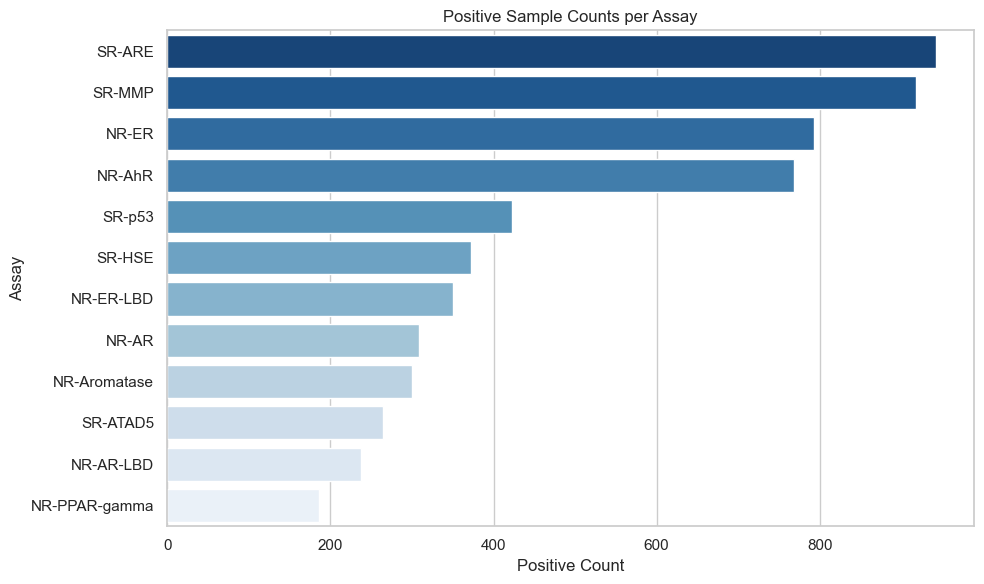

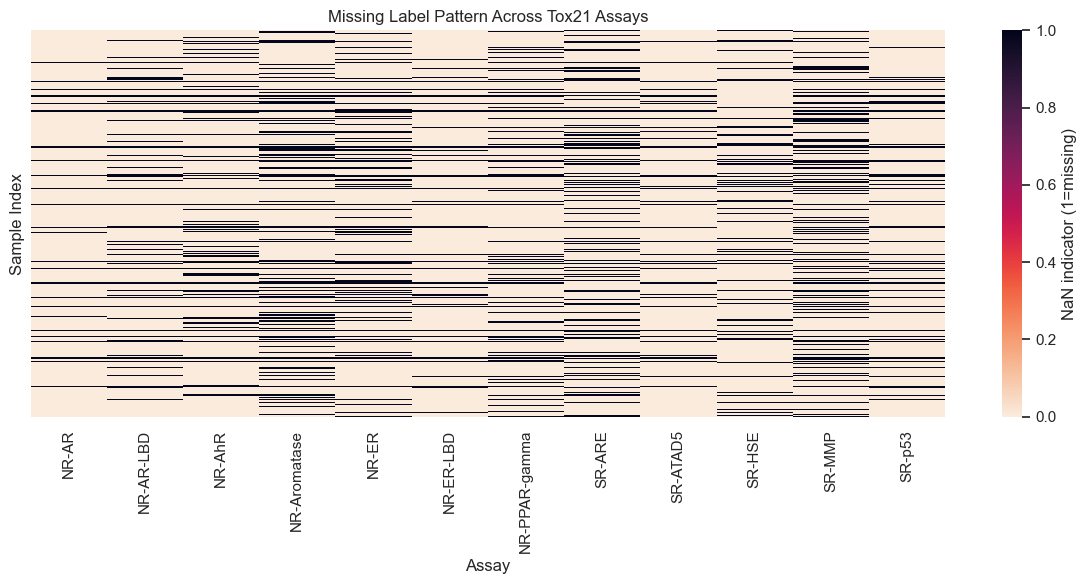

In [13]:
# Bar chart: positive sample counts per assay (sorted descending)
positive_counts_df = imbalance_df.sort_values("positives", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=positive_counts_df,
    x="positives",
    y="assay",
    hue="assay",
    palette="Blues_r",
    dodge=False,
    legend=False
)
plt.title("Positive Sample Counts per Assay")
plt.xlabel("Positive Count")
plt.ylabel("Assay")
plt.tight_layout()
plt.show()

# Heatmap: NaN pattern across all assay labels (1 = missing, 0 = observed)
nan_pattern = df[ASSAY_COLUMNS].isna().astype(int)

plt.figure(figsize=(12, 6))
sns.heatmap(
    nan_pattern,
    cmap="rocket_r",
    cbar_kws={"label": "NaN indicator (1=missing)"},
    yticklabels=False
)
plt.title("Missing Label Pattern Across Tox21 Assays")
plt.xlabel("Assay")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.show()

## 6) EDA Summary: Key Findings and Modeling Implications

### Key Findings
- Label missingness is assay-specific, so each assay has a different effective training size.
- Class imbalance varies substantially across assays, with negative classes often dominating positives.
- SMILES validation quality directly impacts downstream molecular feature generation and model reliability.

### Implications for Modeling
- Train one-vs-rest binary models per assay and exclude only rows with missing labels for that specific assay.
- Use the computed `ratio = negatives / positives` as assay-specific `scale_pos_weight` for XGBoost.
- Use stratified splitting per assay where possible and report PR-AUC / ROC-AUC with assay-level metrics.
- Filter or repair invalid SMILES before descriptor/fingerprint generation to avoid silent feature failures.